In [5]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import integrate
from lmfit import Parameters, minimize

from scipy.special import gamma

from pyazr import azure2

from SRIM import SRIM
from scipy.special import erf

warnings.filterwarnings('ignore')

# Select target
target = 'SUDF#3'

# Boltzmann constant in keV/K
k = 8.617e-5

# Doppler effect
dopp = np.sqrt( 2 * 1.007 / 19 * 0.250 * k * ( 80 + 273 ) )

print( 'Doppler effect =', dopp )

# Read the element stopping data
H_in_F = SRIM( "stopping/H_in_F.stop" )
H_in_H = SRIM( "stopping/H_in_H.stop" )
H_in_Fe = SRIM( "stopping/H_in_Fe.stop" )
H_in_Ta = SRIM( "stopping/H_in_Ta.stop" )
H_in_Ca = SRIM( "stopping/H_in_Ca.stop" )

# Get the effective stopping power for CaF2
def effective_stopping_CaF2( energy, n_inactive=1, n_active=2 ):
    stoichiometry = n_inactive / n_active
    return H_in_F.eval( energy ) + stoichiometry * H_in_Ca.eval( energy )

# Get the effective stopping power for F implanted in Fe
def effective_stopping_Fe( energy, n_inactive=1, n_active=3 ):
    stoichiometry = n_inactive / n_active
    return H_in_F.eval( energy ) + stoichiometry * H_in_Fe.eval( energy )

# Get the effective stopping power for F implanted in Ta
def effective_stopping_Ta( energy, n_inactive=1, n_active=5 ):
    stoichiometry = n_inactive / n_active
    return H_in_F.eval( energy ) + stoichiometry * H_in_Ta.eval( energy )

# Starggling
popt = [0.75324712]
def straggling( x ):
    return popt[0] * np.sqrt( x )

def gaussian( x, x0, s ):
    return np.exp( -(x - x0)**2 / ( s*s*2 ) )

def log_normal( x, x0, s ):
    return ( 1 / ( x * s * np.sqrt( 2 * np.pi ) ) ) * np.exp( - ( np.log( x ) - x0 )**2 / ( 2 * s**2 ) )

def profile( de, theta ):
    # Gaussian
    # if de <= 0: return 0
    # else: return gaussian( de, theta["mean"], theta["std"] )

    # Square
    # return 1 if de > 0 and de < theta["width"] else 0

    # Square
    # if de > 0 and de < theta["width"]:
    #     return 1
    # elif de > theta["width"] and de < theta["width2"] + theta["width"]:
    #     return 0.35
    # elif de > theta["width2"] + theta["width"] and de < theta["width2"] + theta["width"] + theta["width3"]:
    #     # return 0.09
    #     return 3/de
    # else:
    #     return 0
    
    # Triangular (vertical left edge | and then oblique right edge / )
    # if de > 0 and de < theta["width"]:
    #     return 1 - ( de / theta["width"] )
    # else:
    #     return 0

    # Square but with tilted top edge
    if de > 0 and de < theta["width"]:
        return 1# - 0.001*de
    else:
        return 0

def cross_section( x0, theta, de ):
    cross = np.interp( x0, energies * 1e3, extrap )
    return cross 

def reaction_yield( x0, theta, de ):
    cross = cross_section( x0, theta, de ) * 1e-24
    stop = effective_stopping_Ta( x0, theta["n_ta"], theta["n_f"] ) * 1e-15 * 1e-3
    p = profile( de, theta )
    return cross / stop * p

def integrand( x, theta, x0 ):
    de = x0 - x
    
    # Get beam width
    s = np.sqrt( pow( theta["beam"], 2 ) + pow( dopp, 2 ) )
    s = np.sqrt( pow( theta["strag"] * straggling( de ), 2 ) + pow(s, 2) ) if de > 0 else s

    # Convolve the gaussian with the straggling
    array = np.linspace( x - 3 * s, x + 3 * s, 100 )
    gauss = gaussian( array, x, s )

    # Normalize the gaussian
    step = array[1] - array[0]
    norm  = np.sum( gauss ) * step
    
    # Convolve
    conv = np.sum( gauss * reaction_yield( array, theta, de ) ) * step / norm

    #return reaction_yield( x, theta, de )
    return conv

def straggled_profile( x, theta ):
    y = np.zeros( shape=len( x ) )
    for idx in range( len( x ) ):
        nsteps = 500
        xmin, xmax = x[idx] - 100, x[idx]
        dx = np.abs( xmax - xmin ) / nsteps
        y[idx] = integrate.simpson( [ integrand( x_i, theta, x[idx] ) for x_i in np.linspace( xmin, xmax, nsteps) ], dx=dx )
    return y

def model( x, theta ):
    sign = straggled_profile( x, theta )
    back = 0
    return sign + back

def chi2( theta ):
    theta = list( theta.valuesdict().values() )
    mod   = model( x, theta )
    res   = ( obs - mod ) / err
    print( "Chi2: {:10.4f}".format(np.sum(res**2)), end="\r" )
    return res

Doppler effect = 0.02839149987232094


In [6]:
# Read the CSV file of yield for the target
df = pd.read_csv(f"/data0/biasissi/LUNA/19F+p_g+20Ne/Yield_scans/Results/Yield_{target}.csv")

scan = 1

df = df[df["Scan"] == f"Scan {scan}"]

# Recover the very first scan
x, y, y_err = df["Energy"], df["Yield"], df["Yield Error"]

# Refine the yield data by selecting only points with E not NaN and E<300 keV
mask = (~np.isnan(x)) & (x > 300)
x = x[mask]
y = y[mask]
y_err = y_err[mask]

x.to_numpy()
y.to_numpy()
y_err.to_numpy()

eff = 0.0044
q_e = 1.602176634e-19

# N_reactions / N_protons
#y = y * q_e / eff
#yerr = yerr * q_e / eff

# Convert to CM
x = x * 19 / 20.007

# Read cross-section
# data = np.loadtxt( "utils/19F_pag_300-450keV.extrap", usecols=(0,3))
data = np.loadtxt( "utils/all_imp.extrap", usecols=(0,3))
energies, extrap = data[:,0], data[:,1]

In [7]:
# params = Parameters()

# # Beam width (keV)
# params.add('beam', value=0.12, vary=False)

# # Fluorine Iron layer
# params.add('n_fe', value=1.4, vary=True) # Fe stoichiometry
# params.add('n_f', value=1, vary=True) # F stoichiometry

# # Straggling coefficient
# params.add('strag', value=1, vary=False) # Straggling

# # If square
# params.add('width', value=10, vary=True)

# # If gaussian
# params.add('mean', value=7.2, vary=True)    # Center of the profile
# params.add('std', value=5, vary=True)     # Width of the profile

# # Calculate
# grid = np.linspace( 205, 250, 100 )
# y_mod = model( grid, params )

In [8]:
params = Parameters()

# Beam width (keV)
params.add('beam', value=0.12, vary=False)

# Fluorine Tantalum layer
params.add('n_ta', value=3.15, vary=True) # Ta stoichiometry
params.add('n_f', value=1, vary=True) # F stoichiometry

# Straggling coefficient
params.add('strag', value=1, vary=False) # Straggling

# If square
params.add('width', value=72, vary=True)
params.add('width2', value=8.5, vary=True)
params.add('width3', value=27, vary=True)

# If gaussian
params.add('mean', value=4.5, vary=True)    # Center of the profile
params.add('std', value=3.25, vary=True)     # Width of the profile

# Calculate
grid = np.linspace( 310, 400, 150 )
y_mod = model( grid, params )

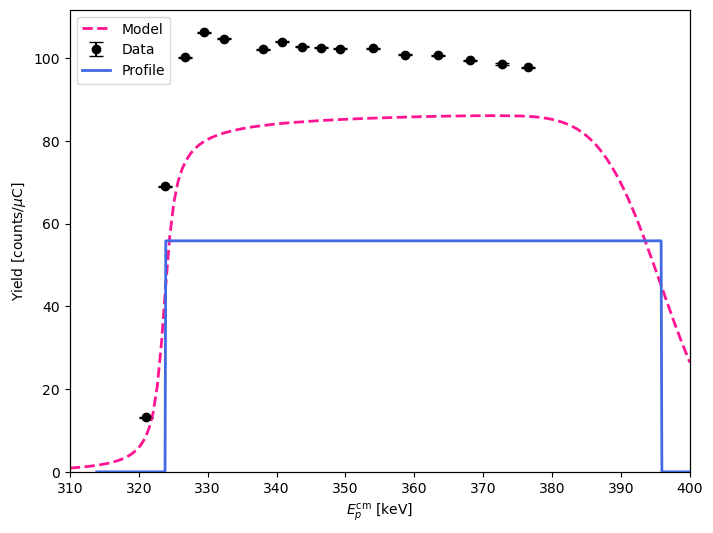

323.9

In [9]:
# Scale
scale_model = 1

fig, ax = plt.subplots( figsize=(8,6) )

# Plot
ax.errorbar( x, y, yerr=y_err, fmt='o', label='Data', color='black', capsize=5 )
ax.plot( grid, y_mod / q_e / 1e6 * eff, ls='dashed', lw=2, color='deeppink', label='Model' )

ax.set_ylabel( r'Yield [counts/$\mu$C]')
ax.set_xlabel( r'$E_p^\text{cm}$ [keV]' )

ax.set_ylim(0, None)

# Plot cross section with the same scale
# grid_cross = np.linspace( 205, 250, 10000 )
# y_cross = np.interp( grid_cross, energies * 1e3, extrap )
# y_cross = y_cross / np.max( y_cross ) * np.max( y_mod ) * 0.9
# plt.plot( grid_cross, y_cross, '--', lw=2, label='Cross Section' )

ax2 = plt.twinx()
grid_profile = np.linspace( -10, 100, 1000 )
p = []
for de in grid_profile:
    p.append( profile( de, params ) )
p = np.array( p )
grid_profile += 323.9
ax2.plot( grid_profile, p, ls='solid', lw=2, label='Profile', color='royalblue' )

# Put ax and ax2 legends together the legends
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# Remove all labels and ticks from ax2
ax2.set_yticks([])
ax2.set_ylabel('')

ax2.set_xlim(310, 400)
ax2.set_ylim(0, 2)

plt.savefig( f"results/{target}_340_scan{scan}.png", dpi=300, bbox_inches='tight' )
plt.show( )



227.9
214.8
323.9